# Dataset preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


In [2]:
gates_counts = pd.read_csv('files/extracted_info.csv')
gates_counts

,NAME,ALL_GATES,USED_GATES,IDA,INVA,AND2,OR2,XOR2,NAND2,NOR2,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
0,mult8_cgp14ep_ep13107_wc0_2_rcam,320,319,0,0,167,48,104,0,0,...,508899,0.9624,0.0721,39,7,175,16,64,-32,201
1,mult8_cgp14ep_ep13107_wc0_rcam,320,320,0,0,168,48,104,0,0,...,525281,0.9656,0.0750,39,7,176,16,64,-32,203
2,mult8_cgp14ep_ep13107_wc0_wtmcla,490,381,0,2,203,66,110,0,0,...,521724,0.9528,0.0630,23,7,212,23,64,-16,205
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,347,325,0,4,165,53,103,0,0,...,465970,0.9508,0.0708,25,6,173,19,64,-19,185
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,347,328,0,4,167,53,104,0,0,...,506924,0.9634,0.0732,25,6,175,20,64,-19,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24901,mult8_cgp14ep_ep65536_wc9_csamrca,320,300,0,1,155,47,96,0,0,...,238839,0.9600,0.0267,28,3,163,16,59,-25,182
24902,mult8_cgp14ep_ep65536_wc9_rcam,320,297,0,0,155,45,97,0,0,...,1041397,0.9697,0.0943,36,8,163,16,58,-28,182
24903,mult8_cgp14ep_ep65536_wc9_wtmcla,490,336,0,0,178,58,100,0,0,...,497283,0.9613,0.0268,21,5,186,18,59,-16,186
24904,mult8_cgp14ep_ep65536_wc9_wtmcsa,418,346,0,6,178,57,105,0,0,...,260478,0.9277,0.0231,24,5,186,22,58,-19,193


In [3]:
json_data = pd.read_csv('files/json_data.csv')
json_data.columns = ['NAME', 'CELLS_JSON', 'SEED', 'MAE', 'WCE', 'WCRE', 'PDK45_AREA', 'PDK45_DELAY', 'PDK45_POWER', 'LEVELS']
json_data

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000,746.187006,2.06,415800.0,39
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000,742.901906,2.04,413300.0,39
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000,853.187400,1.07,495500.0,23
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579,746.187003,1.49,414200.0,25
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799,767.774805,1.52,412000.0,25
...,...,...,...,...,...,...,...,...,...,...
24907,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,705.827206,1.40,386900.0,28
24908,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000,669.221806,1.87,395400.0,37
24909,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000,769.182700,1.39,438300.0,22
24910,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000,786.546799,1.31,443800.0,24


In [4]:
df = pd.merge(json_data, gates_counts, left_on='NAME', right_on='NAME', how='inner')
df

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000,746.187006,2.06,415800.0,39,...,508899,0.9624,0.0721,39,7,175,16,64,-32,201
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000,742.901906,2.04,413300.0,39,...,525281,0.9656,0.0750,39,7,176,16,64,-32,203
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000,853.187400,1.07,495500.0,23,...,521724,0.9528,0.0630,23,7,212,23,64,-16,205
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579,746.187003,1.49,414200.0,25,...,465970,0.9508,0.0708,25,6,173,19,64,-19,185
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799,767.774805,1.52,412000.0,25,...,506924,0.9634,0.0732,25,6,175,20,64,-19,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24901,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,705.827206,1.40,386900.0,28,...,238839,0.9600,0.0267,28,3,163,16,59,-25,182
24902,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000,669.221806,1.87,395400.0,37,...,1041397,0.9697,0.0943,36,8,163,16,58,-28,182
24903,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000,769.182700,1.39,438300.0,22,...,497283,0.9613,0.0268,21,5,186,18,59,-16,186
24904,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000,786.546799,1.31,443800.0,24,...,260478,0.9277,0.0231,24,5,186,22,58,-19,193


In [5]:
df_missing = pd.merge(json_data, gates_counts, left_on='NAME', right_on='NAME', how='outer', indicator=True)
df_missing[df_missing['_merge'] != 'both']

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,...,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX,_merge
24583,mult8_cgp14ep_ep65536_wc65025_csamcsa,0,csam_csa,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24584,mult8_cgp14ep_ep65536_wc65025_csamrca,0,csam_rca,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24585,mult8_cgp14ep_ep65536_wc65025_rcam,0,rcam,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24586,mult8_cgp14ep_ep65536_wc65025_wtmcla,0,wtm_cla,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24587,mult8_cgp14ep_ep65536_wc65025_wtmcsa,0,wtm_csa,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
24588,mult8_cgp14ep_ep65536_wc65025_wtmrca,0,wtm_rca,16256.25,65025,100.0,0.0,0.0,0.0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [6]:
df.dtypes

NAME                  object
CELLS_JSON             int64
SEED                  object
MAE                  float64
WCE                    int64
WCRE                 float64
PDK45_AREA           float64
PDK45_DELAY          float64
PDK45_POWER          float64
LEVELS                 int64
ALL_GATES              int64
USED_GATES             int64
IDA                    int64
INVA                   int64
AND2                   int64
OR2                    int64
XOR2                   int64
NAND2                  int64
NOR2                   int64
XNOR2                  int64
TOTAL_AREA           float64
LONGEST PATH           int64
SHARING_FACTOR       float64
WSS                    int64
LSB%                 float64
MSB%                 float64
GLOBAL_MAX_DEPTH       int64
MSB_MAX_DEPTH          int64
MAX_FANOUT             int64
GATES_FANOUT_GT_3      int64
MAX_WIDTH              int64
DEPTH_SKEW             int64
CONGESTION_INDEX       int64
dtype: object

In [7]:
diffs = df[df["USED_GATES"] != df["CELLS_JSON"]]
diffs.shape 


(0, 33)

In [8]:
diff_levels = df[df["LEVELS"] != df["LONGEST PATH"]]
diff_levels.shape
#diff_levels.head(30)
#diff_levels[abs(diff_levels["LEVELS"] - diff_levels["LONGEST PATH"]) == 2]







(24895, 33)

In [9]:
df.drop(columns=['LONGEST PATH'], inplace=True)
df.shape

(24906, 32)

# Dataset analysis

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24906 entries, 0 to 24905
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NAME               24906 non-null  object 
 1   CELLS_JSON         24906 non-null  int64  
 2   SEED               24906 non-null  object 
 3   MAE                24906 non-null  float64
 4   WCE                24906 non-null  int64  
 5   WCRE               24906 non-null  float64
 6   PDK45_AREA         24906 non-null  float64
 7   PDK45_DELAY        24906 non-null  float64
 8   PDK45_POWER        24906 non-null  float64
 9   LEVELS             24906 non-null  int64  
 10  ALL_GATES          24906 non-null  int64  
 11  USED_GATES         24906 non-null  int64  
 12  IDA                24906 non-null  int64  
 13  INVA               24906 non-null  int64  
 14  AND2               24906 non-null  int64  
 15  OR2                24906 non-null  int64  
 16  XOR2               249

In [11]:
# Handling missing values
df.isnull().sum()

NAME                 0
CELLS_JSON           0
SEED                 0
MAE                  0
WCE                  0
WCRE                 0
PDK45_AREA           0
PDK45_DELAY          0
PDK45_POWER          0
LEVELS               0
ALL_GATES            0
USED_GATES           0
IDA                  0
INVA                 0
AND2                 0
OR2                  0
XOR2                 0
NAND2                0
NOR2                 0
XNOR2                0
TOTAL_AREA           0
SHARING_FACTOR       0
WSS                  0
LSB%                 0
MSB%                 0
GLOBAL_MAX_DEPTH     0
MSB_MAX_DEPTH        0
MAX_FANOUT           0
GATES_FANOUT_GT_3    0
MAX_WIDTH            0
DEPTH_SKEW           0
CONGESTION_INDEX     0
dtype: int64

In [12]:
# Check for duplicates
df.duplicated().sum()

0

In [13]:
# Show unique values in "SEED" column and their counts
df['SEED'].value_counts()

SEED
wtm_csa     4218
csam_csa    4202
wtm_cla     4200
csam_rca    4140
rcam        4077
wtm_rca     4069
Name: count, dtype: int64

In [14]:
# Summary statistics
df.describe()

,CELLS_JSON,MAE,WCE,WCRE,PDK45_AREA,PDK45_DELAY,PDK45_POWER,LEVELS,ALL_GATES,USED_GATES,...,WSS,LSB%,MSB%,GLOBAL_MAX_DEPTH,MSB_MAX_DEPTH,MAX_FANOUT,GATES_FANOUT_GT_3,MAX_WIDTH,DEPTH_SKEW,CONGESTION_INDEX
count,24906.000000,24906.000000,24906.000000,2.490600e+04,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,...,2.490600e+04,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000,24906.000000
mean,242.173011,763.627001,5267.406810,1.042279e+03,572.148190,1.210956,300996.048613,22.766442,371.943909,242.173011,...,5.298362e+05,0.819006,0.115571,22.417771,5.527704,134.022485,16.051634,53.837549,-16.687304,109.681402
std,86.251645,1673.129553,9302.001263,9.659348e+03,196.568972,0.408615,124982.919375,7.375686,62.869858,86.251645,...,9.239040e+05,0.225793,0.151780,7.463430,3.777518,45.546985,3.826479,14.107134,7.844291,67.678550
min,1.000000,0.000000,0.000000,0.000000e+00,2.346500,0.040000,301.750000,1.000000,320.000000,1.000000,...,1.000000e+00,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,-35.000000,0.000000
25%,194.000000,15.508177,100.000000,1.000000e+02,474.462295,1.030000,227325.000000,19.000000,320.000000,194.000000,...,2.097722e+05,0.799300,0.053200,19.000000,4.000000,109.000000,15.000000,47.000000,-22.000000,48.000000
50%,272.000000,109.633910,856.000000,1.777778e+02,644.348904,1.270000,352700.000000,24.000000,347.000000,272.000000,...,3.305240e+05,0.918900,0.068300,23.000000,5.000000,150.000000,16.000000,61.000000,-17.000000,125.000000
75%,307.000000,646.066253,5666.000000,3.444444e+02,714.743903,1.430000,396800.000000,27.000000,418.000000,307.000000,...,4.429720e+05,0.957800,0.092800,27.000000,6.000000,168.000000,18.000000,64.000000,-13.000000,168.000000
max,381.000000,16162.875000,64770.000000,1.016700e+06,954.556194,2.360000,532900.000000,40.000000,490.000000,381.000000,...,1.274368e+07,1.000000,1.000000,40.000000,38.000000,212.000000,27.000000,66.000000,4.000000,267.000000


In [15]:
fast_features = ['ALL_GATES','USED_GATES', 'CELLS_JSON', 'LEVELS', 'IDA', 'INVA', 'AND2', 'OR2', 'XOR2', 'NAND2', 'NOR2', 'XNOR2', 'TOTAL_AREA', 
                 'WSS', 'LSB%', 'MSB%', 'GLOBAL_MAX_DEPTH', 'MSB_MAX_DEPTH', 'MAX_FANOUT', 'GATES_FANOUT_GT_3', 'MAX_WIDTH', 'DEPTH_SKEW', 'CONGESTION_INDEX']
slow_targets = ['MAE', 'WCE', 'WCRE', 'PDK45_AREA', 'PDK45_DELAY', 'PDK45_POWER']
error_targets = ['MAE', 'WCE', 'WCRE']


# Error prediction analysis

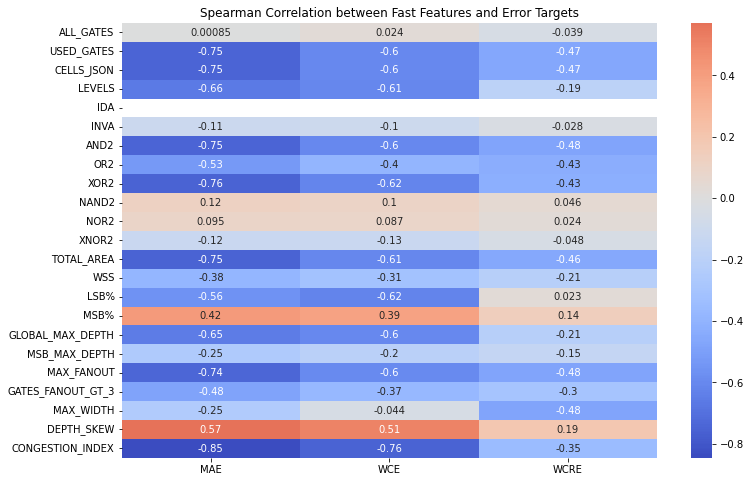

In [16]:
# Calculate spearman correlation between fast features and MAE, WCE, WCRE
correlation_matrix = df[fast_features + error_targets].corr(method='spearman')
correlation_matrix = correlation_matrix[error_targets].loc[fast_features]
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Spearman Correlation between Fast Features and Error Targets')
plt.show()

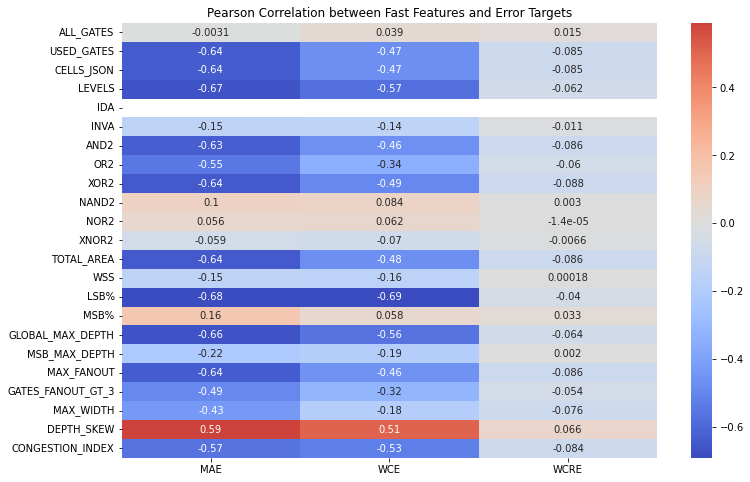

In [17]:
# Calculate pearson correlation between fast features and MAE, WCE, WCRE
correlation_matrix = df[fast_features + error_targets].corr(method='pearson')
correlation_matrix = correlation_matrix[error_targets].loc[fast_features]
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation between Fast Features and Error Targets')
plt.show()

In [18]:
df.drop(columns=['ALL_GATES', 'CELLS_JSON'], inplace=True)

In [19]:
df.drop(columns=['LEVELS', 'MSB_MAX_DEPTH'], inplace=True)

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [21]:
# remove 'ALL_GATES', 'CELLS_JSON', 'LEVELS', 'MSB_MAX_DEPTH' from fast features
fast_features = [feature for feature in fast_features if feature not in ['ALL_GATES', 'CELLS_JSON', 'LEVELS', 'MSB_MAX_DEPTH']]

R2 Score (Raw): 0.7806
R2 Score (Log): 0.9358


C:\Users\nivan\AppData\Local\Temp\ipykernel_11460\4278506345.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_raw.values, y=importances_raw.index, ax=ax1, palette='viridis')
C:\Users\nivan\AppData\Local\Temp\ipykernel_11460\4278506345.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_log.values, y=importances_log.index, ax=ax2, palette='magma')


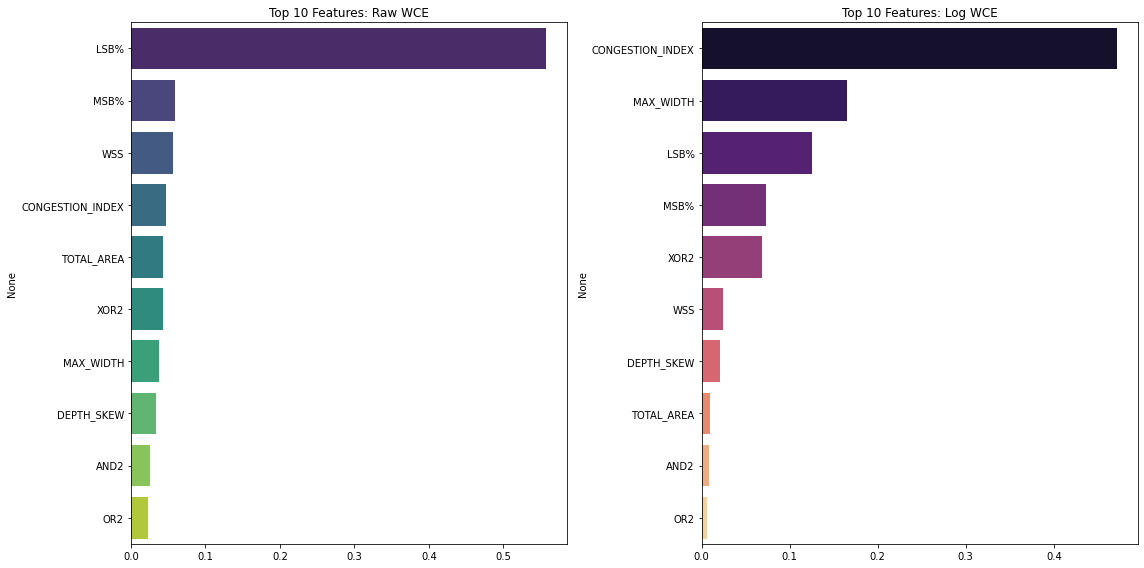

In [22]:
# 1. Setup Targets
target = 'WCE'
X = df[fast_features].fillna(0)
y_raw = df[target]
y_log = np.log1p(df[target]) # log1p handles log(0) safely

# 2. Train-Test Split
X_train, X_test, y_train_raw, y_test_raw = train_test_split(X, y_raw, test_size=0.2, random_state=42)
_, _, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 3. Models
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42)
rf_log = RandomForestRegressor(n_estimators=100, random_state=42)

rf_raw.fit(X_train, y_train_raw)
rf_log.fit(X_train, y_train_log)

# 4. Evaluation
print(f"R2 Score (Raw): {r2_score(y_test_raw, rf_raw.predict(X_test)):.4f}")
print(f"R2 Score (Log): {r2_score(y_test_log, rf_log.predict(X_test)):.4f}")

# 5. Visualization of Feature Importances
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Raw Importance
importances_raw = pd.Series(rf_raw.feature_importances_, index=fast_features).nlargest(10)
sns.barplot(x=importances_raw.values, y=importances_raw.index, ax=ax1, palette='viridis')
ax1.set_title(f"Top 10 Features: Raw {target}")

# Log Importance
importances_log = pd.Series(rf_log.feature_importances_, index=fast_features).nlargest(10)
sns.barplot(x=importances_log.values, y=importances_log.index, ax=ax2, palette='magma')
ax2.set_title(f"Top 10 Features: Log {target}")

plt.tight_layout()
plt.show()

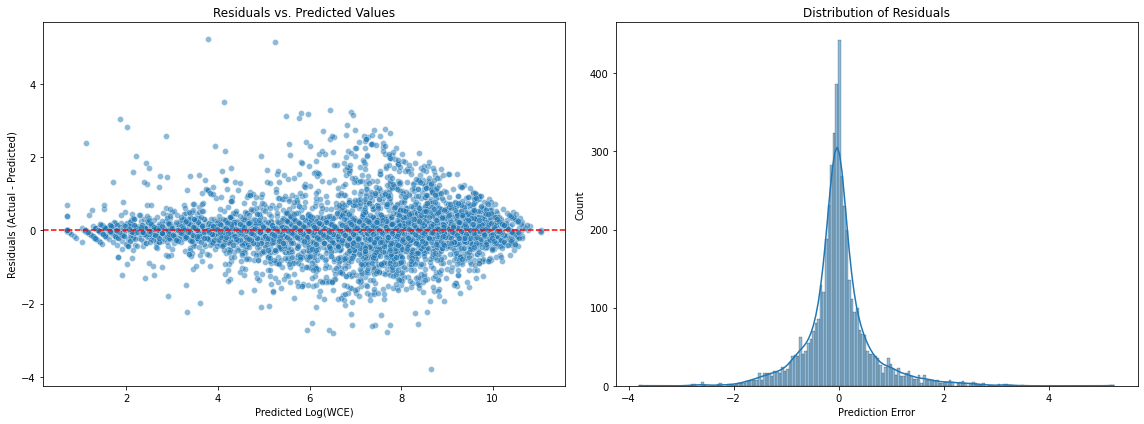

In [23]:
# Calculate residuals for the Log model
y_pred_log = rf_log.predict(X_test)
residuals = y_test_log - y_pred_log

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residual Plot
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.5, ax=ax1)
ax1.axhline(0, color='red', linestyle='--')
ax1.set_xlabel('Predicted Log(WCE)')
ax1.set_ylabel('Residuals (Actual - Predicted)')
ax1.set_title('Residuals vs. Predicted Values')

# 2. Histogram of Residuals
sns.histplot(residuals, kde=True, ax=ax2)
ax2.set_title('Distribution of Residuals')
ax2.set_xlabel('Prediction Error')

plt.tight_layout()
plt.show()

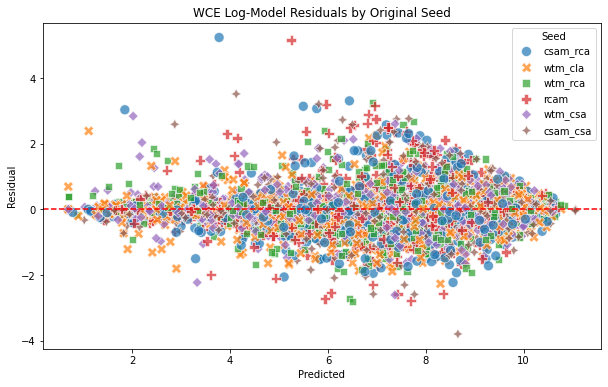

In [24]:
# Assuming 'y_test_log' are your actuals and 'rf_log_mae.predict(X_test)' are predictions
# And 'df' contains the 'SEED' column for the test indices

test_indices = X_test.index
results_df = pd.DataFrame({
    'Actual': y_test_log,
    'Predicted': rf_log.predict(X_test),
    'Seed': df.loc[test_indices, 'SEED']
})
results_df['Residual'] = results_df['Actual'] - results_df['Predicted']

plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x='Predicted', y='Residual', hue='Seed', style='Seed', s=100, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.title("WCE Log-Model Residuals by Original Seed")
plt.show()

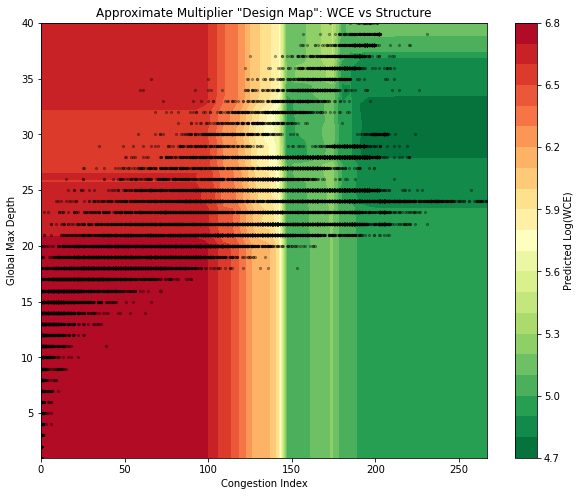

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a grid of the two top features
congestion_range = np.linspace(X['CONGESTION_INDEX'].min(), X['CONGESTION_INDEX'].max(), 50)
depth_range = np.linspace(X['MAX_WIDTH'].min(), X['GLOBAL_MAX_DEPTH'].max(), 50)
C, D = np.meshgrid(congestion_range, depth_range)

# 2. Prepare "Average" data for all other features
median_features = X.median().values
grid_data = np.tile(median_features, (2500, 1))
grid_df = pd.DataFrame(grid_data, columns=X.columns)

# 3. Inject our grid values
grid_df['CONGESTION_INDEX'] = C.ravel()
grid_df['GLOBAL_MAX_DEPTH'] = D.ravel()

# 4. Predict and Reshape
Z = rf_log.predict(grid_df).reshape(50, 50)

# 5. Plot the Heatmap
plt.figure(figsize=(10, 8))
cp = plt.contourf(C, D, Z, cmap='RdYlGn_r', levels=20)
plt.colorbar(cp, label='Predicted Log(WCE)')
plt.scatter(X['CONGESTION_INDEX'], X['GLOBAL_MAX_DEPTH'], c='black', s=5, alpha=0.3) # Actual data points
plt.xlabel('Congestion Index')
plt.ylabel('Global Max Depth')
plt.title('Approximate Multiplier "Design Map": WCE vs Structure')
plt.show()

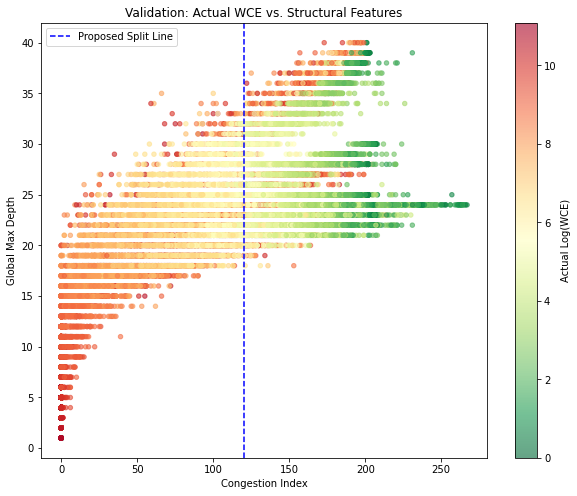

In [26]:
plt.figure(figsize=(10, 8))
# Use log1p for the color scale to make the transition visible
sc = plt.scatter(df['CONGESTION_INDEX'], df['GLOBAL_MAX_DEPTH'], 
                 c=np.log1p(df['WCE']), cmap='RdYlGn_r', s=20, alpha=0.6)
plt.colorbar(sc, label='Actual Log(WCE)')
plt.axvline(x=120, color='blue', linestyle='--', label='Proposed Split Line')
plt.xlabel('Congestion Index')
plt.ylabel('Global Max Depth')
plt.title('Validation: Actual WCE vs. Structural Features')
plt.legend()
plt.show()

C:\Users\nivan\AppData\Local\Temp\ipykernel_11460\388733115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Zone', y=np.log1p(df['WCE']), data=df, palette='Set2')


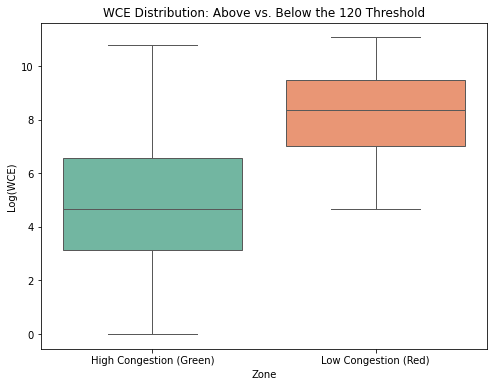

In [27]:
df['Zone'] = np.where(df['CONGESTION_INDEX'] > 120, 'High Congestion (Green)', 'Low Congestion (Red)')

plt.figure(figsize=(8, 6))
sns.boxplot(x='Zone', y=np.log1p(df['WCE']), data=df, palette='Set2')
plt.title('WCE Distribution: Above vs. Below the 120 Threshold')
plt.ylabel('Log(WCE)')
plt.show()

In [28]:
import plotly.express as px

# Interactive 3D plot to spin and find the separation
fig = px.scatter_3d(df, 
                    x='CONGESTION_INDEX', 
                    y='GLOBAL_MAX_DEPTH', 
                    z='LSB%',  # Or use 'XOR2'
                    color=np.log1p(df['WCE']),
                    color_continuous_scale='RdYlGn_r',
                    title="Finding the Hidden Dimension")
fig.show()

In [34]:
import plotly.express as px

# Interactive 3D plot to spin and find the separation
fig = px.scatter_3d(df, 
                    x='CONGESTION_INDEX', 
                    y='GLOBAL_MAX_DEPTH', 
                    z='XOR2',
                    color=np.log1p(df['MAE']),
                    color_continuous_scale='RdYlGn_r',
                    title="Finding the Hidden Dimension")
fig.show()

In [35]:
import plotly.express as px

# Interactive 3D plot to spin and find the separation
fig = px.scatter_3d(df, 
                    x='CONGESTION_INDEX', 
                    y='GLOBAL_MAX_DEPTH', 
                    z='MSB%',  # Or use 'XOR2'
                    color=np.log1p(df['MAE']),
                    color_continuous_scale='RdYlGn_r',
                    title="Finding the Hidden Dimension")
fig.show()

In [36]:
# Calculate what the 2-feature model MISSED
y_pred_2feature = rf_log_mae.predict(X_test)
residuals = y_test_log - y_pred_2feature

# Correlate residuals with the candidates
candidates = ['MSB%', 'LSB%', 'XOR2']
for c in candidates:
    corr = pd.Series(residuals).corr(X_test[c], method='spearman')
    print(f"Correlation between {c} and Model Error: {corr:.4f}")

Correlation between MSB% and Model Error: 0.0146
Correlation between LSB% and Model Error: 0.0114
Correlation between XOR2 and Model Error: -0.0236


In [37]:
from sklearn.model_selection import cross_val_score

base_features = ['CONGESTION_INDEX', 'GLOBAL_MAX_DEPTH']
candidates = ['MSB%', 'LSB%', 'XOR2']

results = {}

for candidate in candidates:
    features = base_features + [candidate]
    X_temp = df[features]
    
    # Using Cross-Validation for a "Fair" fight
    scores = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), 
                             X_temp, y_log, cv=5, scoring='r2')
    results[candidate] = np.mean(scores)

# Sort and print the leaderboard
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
print("--- Leaderboard: The Best Third Identifier ---")
for name, score in sorted_results:
    print(f"{name}: Average R2 Score = {score:.4f}")

--- Leaderboard: The Best Third Identifier ---
MSB%: Average R2 Score = 0.7478
LSB%: Average R2 Score = 0.6337
XOR2: Average R2 Score = 0.6092


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Create the Bins (Labels)
def label_mae(mae):
    if mae < 100: return 0    # Low
    if mae < 1000: return 1   # Medium
    return 2                  # High

df['MAE_Class'] = df['MAE'].apply(label_mae)

# 2. Train the Classifier
X_class = df[['CONGESTION_INDEX', 'GLOBAL_MAX_DEPTH', 'MSB%']]
y_class = df['MAE_Class']

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_class, y_class)

# 3. Predict the Bin
y_pred_class = clf.predict(X_class)

In [39]:
print(classification_report(y_class, y_pred_class, 
                            target_names=['Low', 'Medium', 'High']))

              precision    recall  f1-score   support

         Low       0.99      1.00      1.00     12181
      Medium       0.99      0.99      0.99      7941
        High       1.00      0.99      1.00      4784

    accuracy                           0.99     24906
   macro avg       1.00      0.99      0.99     24906
weighted avg       0.99      0.99      0.99     24906



In [40]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Create the 5 Bins
def get_5_bins(mae):
    if mae < 50: return 0
    if mae < 200: return 1
    if mae < 800: return 2
    if mae < 3000: return 3
    return 4

df['MAE_Grade'] = df['MAE'].apply(get_5_bins)

# 2. Train using your "Winning Three" (Congestion, Depth, MSB%)
X_5class = df[['CONGESTION_INDEX', 'GLOBAL_MAX_DEPTH', 'MSB%']]
y_5class = df['MAE_Grade']

clf_5 = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
clf_5.fit(X_5class, y_5class)

# 3. Predict
y_pred_5 = clf_5.predict(X_5class)

In [41]:
print(f"Overall Accuracy for 5-Bin Screening: {accuracy_score(y_5class, y_pred_5):.4f}")
print("\nDetailed Performance per Tier:")
print(classification_report(y_5class, y_pred_5, 
                            target_names=['Elite', 'High', 'Mid', 'Low', 'Broken']))

Overall Accuracy for 5-Bin Screening: 0.8113

Detailed Performance per Tier:
              precision    recall  f1-score   support

       Elite       0.85      0.96      0.90      9791
        High       0.75      0.72      0.73      4786
         Mid       0.73      0.74      0.74      4826
         Low       0.83      0.66      0.73      3617
      Broken       0.89      0.76      0.82      1886

    accuracy                           0.81     24906
   macro avg       0.81      0.77      0.79     24906
weighted avg       0.81      0.81      0.81     24906



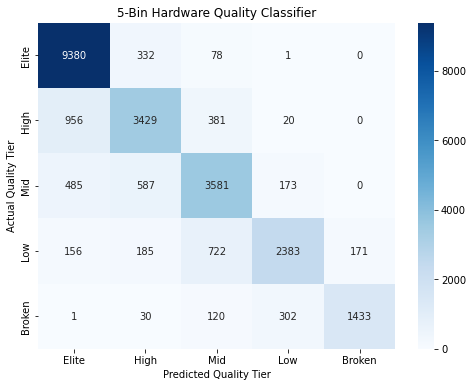

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_5class, y_pred_5)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Elite', 'High', 'Mid', 'Low', 'Broken'],
            yticklabels=['Elite', 'High', 'Mid', 'Low', 'Broken'])
plt.ylabel('Actual Quality Tier')
plt.xlabel('Predicted Quality Tier')
plt.title('5-Bin Hardware Quality Classifier')
plt.show()

In [43]:
# Assuming your dataframe has a column 'SEED_TYPE' (e.g., 'Wallace', 'Dadda', etc.)
seeds = df['SEED'].unique()

print(f"{'Seed Architecture':<20} | {'5-Bin Accuracy':<15} | {'Sample Count':<10}")
print("-" * 50)

for seed in seeds:
    # Filter data for this specific seed
    seed_mask = (df['SEED'] == seed)
    X_seed = X_5class[seed_mask]
    y_seed = y_5class[seed_mask]
    
    # Get predictions for this seed's subset
    y_seed_pred = clf_5.predict(X_seed)
    acc = accuracy_score(y_seed, y_seed_pred)
    
    print(f"{seed:<20} | {acc:<15.4f} | {len(y_seed):<10}")

Seed Architecture    | 5-Bin Accuracy  | Sample Count
--------------------------------------------------
rcam                 | 0.8469          | 4077      
wtm_cla              | 0.8388          | 4200      
csam_csa             | 0.7584          | 4202      
wtm_csa              | 0.8350          | 4218      
wtm_rca              | 0.8211          | 4069      
csam_rca             | 0.7681          | 4140      


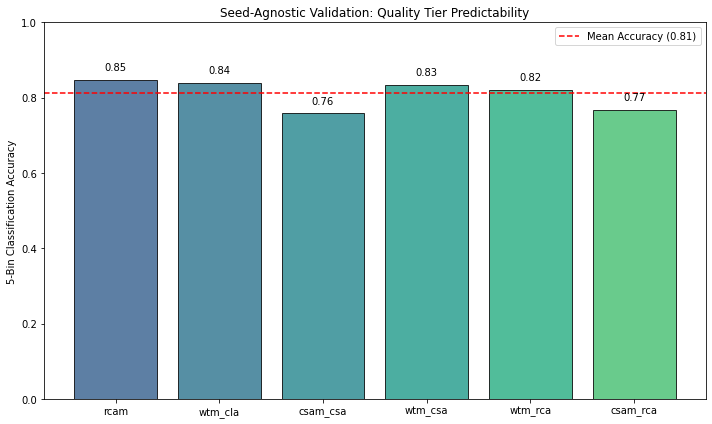

--- Final Metrics ---
Mean Accuracy across all seeds: 0.8114
Structural Determinism Coefficient (C_sd): 0.9569


In [45]:
# 1. Calculate accuracy per Seed Architecture
seed_accuracies = {}
seeds = df['SEED'].unique()

for seed in seeds:
    mask = (df['SEED'] == seed)
    y_true = y_5class[mask]
    y_pred = clf_5.predict(X_5class[mask])
    seed_accuracies[seed] = accuracy_score(y_true, y_pred)

# 2. Calculate the Structural Determinism Coefficient (C_sd)
acc_values = list(seed_accuracies.values())
mean_acc = np.mean(acc_values)
std_acc = np.std(acc_values)
# C_sd = 1 - (Coefficient of Variation)
c_sd = 1 - (std_acc / mean_acc)

# 3. Create the Insight Graph
plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.7, len(seeds)))
bars = plt.bar(seed_accuracies.keys(), acc_values, color=colors, alpha=0.8, edgecolor='black')

# Formatting
plt.axhline(y=mean_acc, color='red', linestyle='--', label=f'Mean Accuracy ({mean_acc:.2f})')
plt.ylim(0, 1.0)
plt.ylabel('5-Bin Classification Accuracy')
plt.title('Seed-Agnostic Validation: Quality Tier Predictability')
plt.legend()

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"--- Final Metrics ---")
print(f"Mean Accuracy across all seeds: {mean_acc:.4f}")
print(f"Structural Determinism Coefficient (C_sd): {c_sd:.4f}")

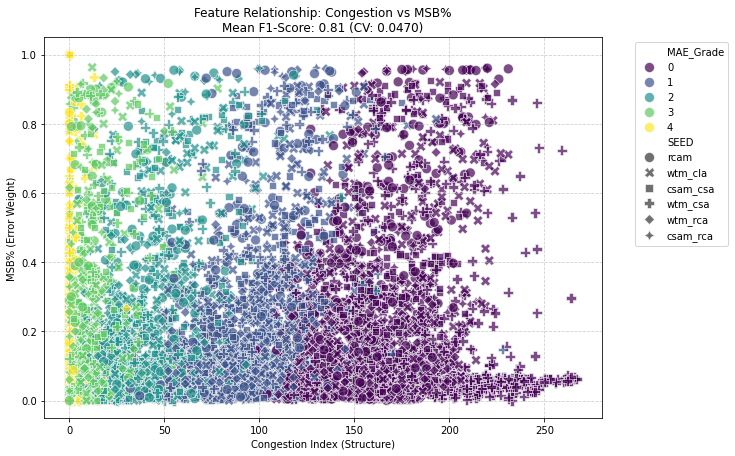

Overall Predictability (F1): 0.81
Seed Sensitivity (CV): 0.0470 (Lower is better)


In [47]:
import seaborn as sns
from sklearn.metrics import f1_score

# 1. Calculate F1-Score per Seed for Stability Metric
f1_scores = []
for seed in df['SEED'].unique():
    mask = df['SEED'] == seed
    f1 = f1_score(y_5class[mask], clf_5.predict(X_5class[mask]), average='weighted')
    f1_scores.append(f1)

f1_mean = np.mean(f1_scores)
f1_cv = np.std(f1_scores) / f1_mean

# 2. The "Zoned" Relationship Graph
plt.figure(figsize=(10, 7))
# Plotting Congestion vs MSB%, colored by the 5-Bin Grade, with different shapes for Seeds
sns.scatterplot(data=df, x='CONGESTION_INDEX', y='MSB%', 
                hue='MAE_Grade', style='SEED', 
                palette='viridis', alpha=0.7, s=100)

plt.title(f'Feature Relationship: Congestion vs MSB%\nMean F1-Score: {f1_mean:.2f} (CV: {f1_cv:.4f})')
plt.xlabel('Congestion Index (Structure)')
plt.ylabel('MSB% (Error Weight)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Overall Predictability (F1): {f1_mean:.2f}")
print(f"Seed Sensitivity (CV): {f1_cv:.4f} (Lower is better)")

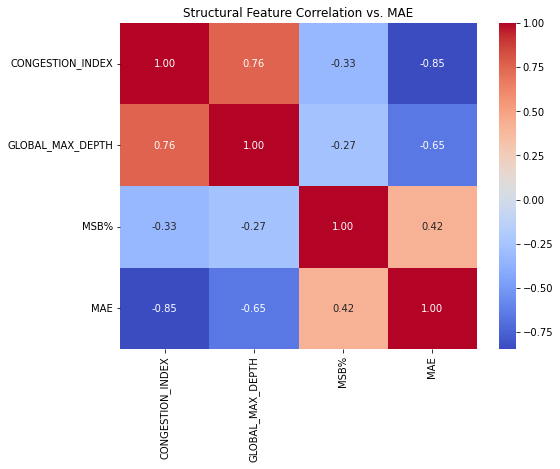

In [48]:
# 1. Select the "Big Three" and the target
cols_to_corr = ['CONGESTION_INDEX', 'GLOBAL_MAX_DEPTH', 'MSB%', 'MAE']
corr_matrix = df[cols_to_corr].corr(method='spearman')

# 2. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structural Feature Correlation vs. MAE")
plt.show()

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning:

An input array is constant; the correlation coefficient is not defined.



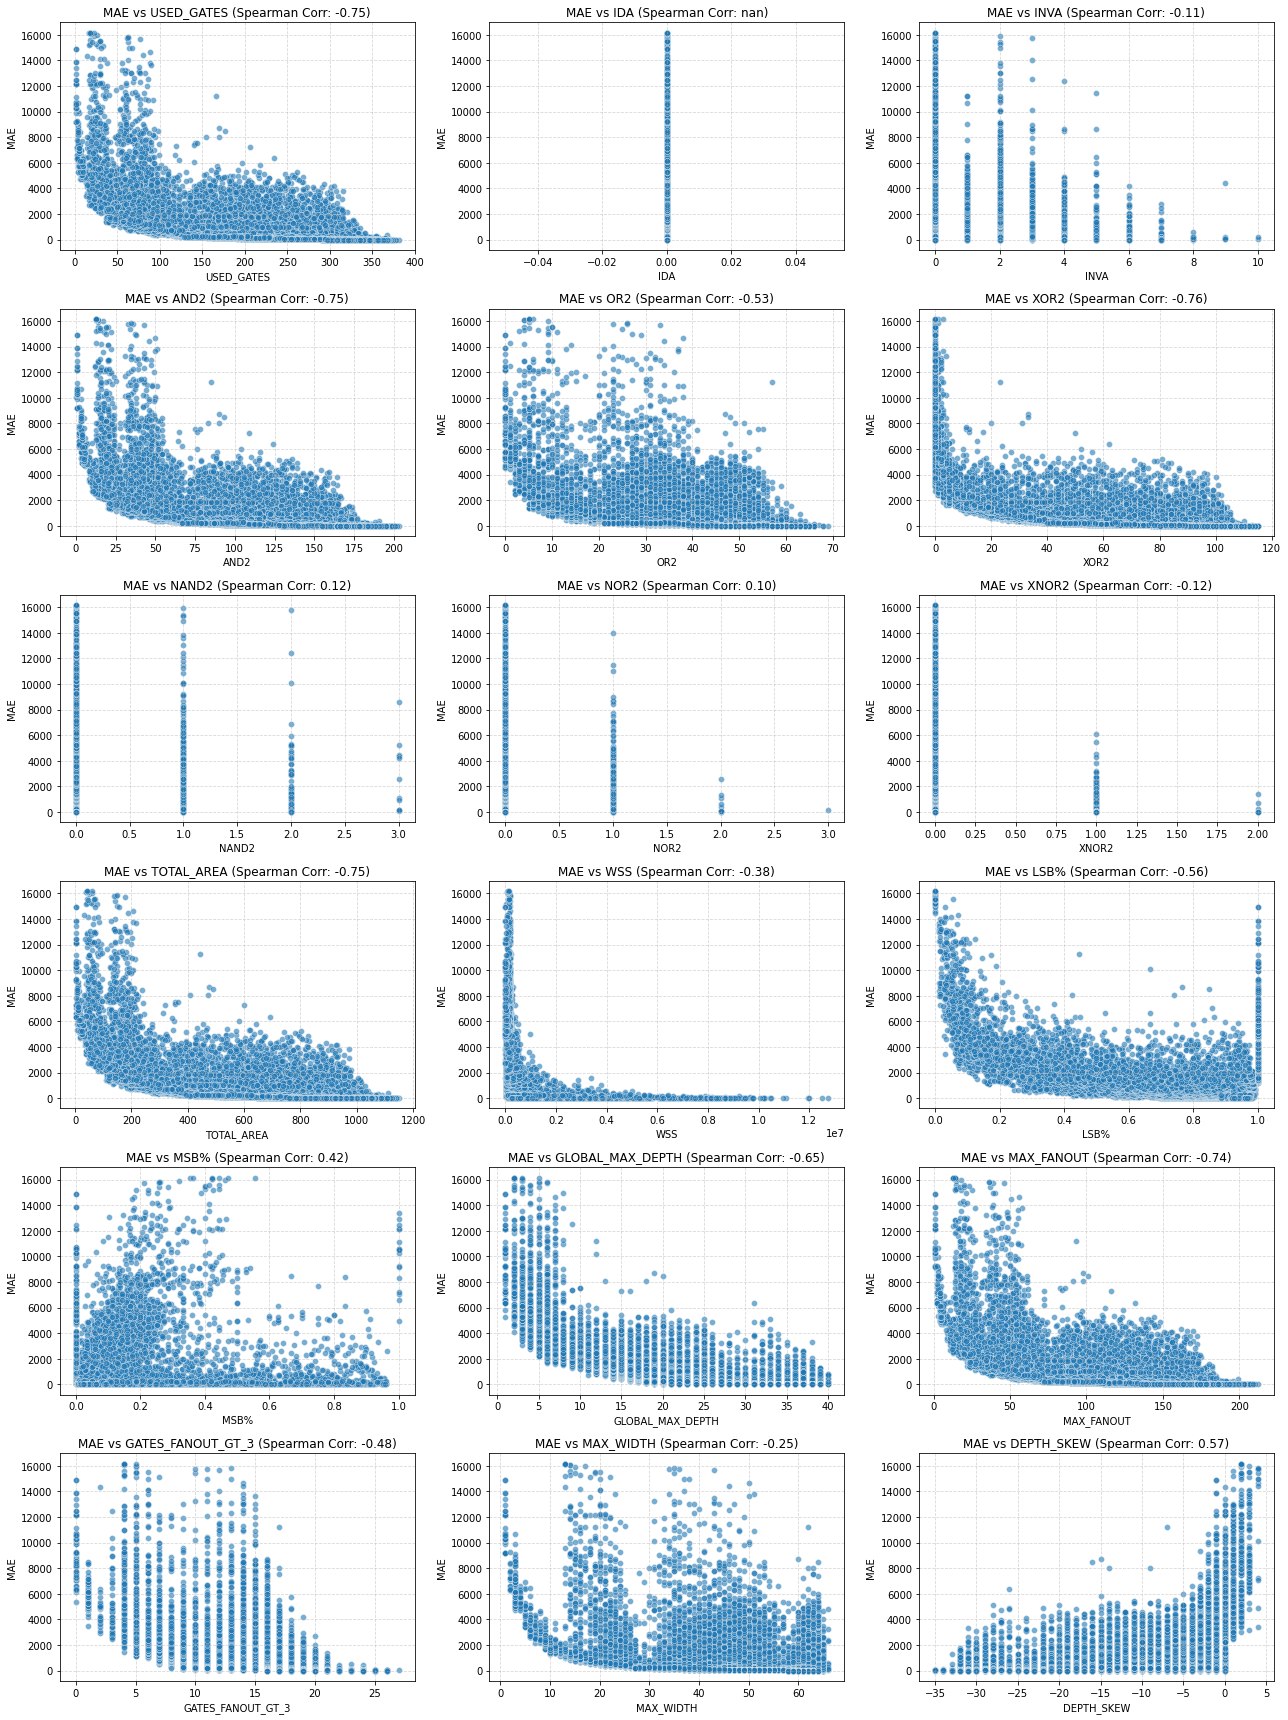

In [61]:
# Scatter plot: MAE vs all other features that have > 0.4 correlation
# in a grid layout for better visibility
# include correlation coefficinet in the title of each subplot


fig, axes = plt.subplots(6, 3, figsize=(18, 24))
axes = axes.flatten()

for i, feature in enumerate(fast_features[:-1]):
    corr = df[feature].corr(df['MAE'], method='spearman')
    sns.scatterplot(data=df, x=feature, y='MAE', ax=axes[i], alpha=0.6)
    axes[i].set_title(f'MAE vs {feature} (Spearman Corr: {corr:.2f})')
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



In [63]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# 1. Prepare a list of "Size" features vs "Structural" features
X_vif = df[fast_features + ['MAE']].dropna()

# 2. Standardize (VIF requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = fast_features + ['MAE']
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(fast_features + ['MAE']))]

print("--- Multicollinearity Report ---")
print(vif_data.sort_values(by='VIF', ascending=False))

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning:

invalid value encountered in scalar divide



--- Multicollinearity Report ---
              Feature          VIF
0          USED_GATES          inf
6               NAND2          inf
2                INVA          inf
8               XNOR2          inf
7                NOR2          inf
9          TOTAL_AREA          inf
5                XOR2          inf
4                 OR2          inf
3                AND2          inf
14         MAX_FANOUT  4519.493529
17         DEPTH_SKEW    21.929071
13   GLOBAL_MAX_DEPTH    20.615503
16          MAX_WIDTH    15.494005
15  GATES_FANOUT_GT_3    10.795906
18   CONGESTION_INDEX     9.216255
11               LSB%     6.875140
12               MSB%     5.593598
19                MAE     3.336547
10                WSS     3.139678
1                 IDA          NaN


In [64]:
# 1. Prepare a list of "Size" features vs "Structural" features
X_vif = df[fast_features].dropna()

# 2. Standardize (VIF requires scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vif)

# 3. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = fast_features
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(len(fast_features))]

print("--- Multicollinearity Report ---")
print(vif_data.sort_values(by='VIF', ascending=False))

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning:

divide by zero encountered in scalar divide

C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning:

invalid value encountered in scalar divide



--- Multicollinearity Report ---
              Feature          VIF
0          USED_GATES          inf
3                AND2          inf
4                 OR2          inf
5                XOR2          inf
6               NAND2          inf
7                NOR2          inf
8               XNOR2          inf
9          TOTAL_AREA          inf
2                INVA          inf
14         MAX_FANOUT  4453.404913
17         DEPTH_SKEW    21.903136
13   GLOBAL_MAX_DEPTH    20.094234
16          MAX_WIDTH    15.401458
15  GATES_FANOUT_GT_3    10.283346
18   CONGESTION_INDEX     7.936065
12               MSB%     5.575385
11               LSB%     5.531030
10                WSS     3.128239
1                 IDA          NaN


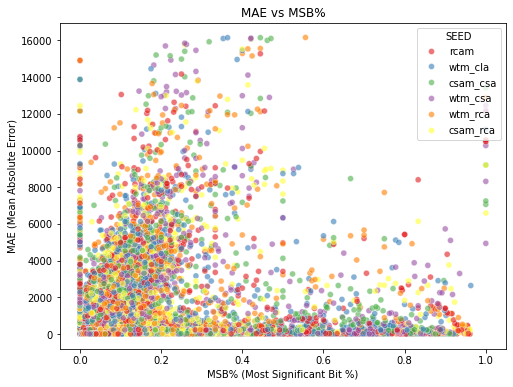

In [66]:
# plot mae vs msb color by seed
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='MSB%', y='MAE', alpha=0.6, hue='SEED', palette='Set1')
plt.title('MAE vs MSB%')
plt.xlabel('MSB% (Most Significant Bit %)')
plt.ylabel('MAE (Mean Absolute Error)')
plt.show()